In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tyche_client import TycheClient
from matplotlib.ticker import PercentFormatter

from dotenv import load_dotenv

load_dotenv(override=True)  # reads TYCHE_BASE_URL / TYCHE_API_KEY from a local .env file (see .env.example)
# override=True: without it, editing .env and re-running this cell in an already-running
# kernel silently keeps the OLD value, since load_dotenv() won't clobber an env var that
# a previous run of this same cell already set -- a real bug this caused once, not hypothetical.

client = TycheClient(
    os.getenv("TYCHE_BASE_URL", "http://localhost:8000"),
    os.getenv("TYCHE_API_KEY", "tyk_paste_your_key_here").strip(),
)

In [40]:
vix = client.series("vix", "VIX").sort_index()
spy = client.prices("SPY", start="1990-01-01")["Close"].sort_index()
print(f"VIX: {len(vix)} obs, {vix.index.min().date()} -> {vix.index.max().date()}")
print(f"SPY: {len(spy)} obs, {spy.index.min().date()} -> {spy.index.max().date()}")

VIX: 9242 obs, 1990-01-02 -> 2026-08-03
SPY: 7542 obs, 1996-08-12 -> 2026-08-04


In [38]:
FORWARD_DAYS = 20

spy_log_ret = np.log(spy).diff()

fwd_realized_vol = (
    spy_log_ret.shift(-1).rolling(FORWARD_DAYS).std().shift(-(FORWARD_DAYS - 1)) * np.sqrt(252) * 100
)

df = pd.concat([vix,spy,fwd_realized_vol.rename("fwd_realized_vol")],axis=1)

/var/folders/sk/b2sc5qdj3pv0n081pvpxq4_w0000gn/T/ipykernel_74741/2607760747.py:9: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat([vix,spy,fwd_realized_vol.rename("fwd_realized_vol")],axis=1)


In [39]:
df.tail()

,VIX,Close,fwd_realized_vol
date,,,
2026-07-29,20.66,729.460022,NaN
2026-07-30,17.09,741.690002,NaN
2026-07-31,15.99,747.030029,NaN
2026-08-03,15.86,757.669983,NaN
2026-08-04,NaN,771.229980,NaN


In [41]:
df['vix_diff'] = df['VIX'].pct_change()
df['spy_diff']=df['Close'].pct_change()
df['5d_fwd']=df['Close'].pct_change(-5)
df['10d_fwd']=df['Close'].pct_change(-10)
df['20d_fwd']=df['Close'].pct_change(-20)
df['60d_fwd']=df['Close'].pct_change(-60)

In [42]:
df = df['1997':]
df

,VIX,Close,fwd_realized_vol,vix_diff,spy_diff,5d_fwd,10d_fwd,20d_fwd,60d_fwd
date,,,,,,,,,
1997-01-02,21.14,74.031250,14.045340,0.010516,0.002539,-0.017012,-0.039724,-0.056927,-0.017828
1997-01-03,19.13,75.093750,13.451873,-0.095080,0.014352,-0.013547,-0.031829,-0.042248,-0.010093
1997-01-06,19.89,74.437500,12.816566,0.039728,-0.008739,-0.020761,-0.041449,-0.053447,-0.000839
1997-01-07,19.35,75.343750,12.407657,-0.027149,0.012175,-0.021112,-0.037525,-0.047788,0.005841
1997-01-08,20.24,74.687500,14.046253,0.045995,-0.008710,-0.027269,-0.052715,-0.038036,-0.015245
...,...,...,...,...,...,...,...,...,...
2026-07-29,20.66,729.460022,NaN,0.134541,-0.015387,NaN,NaN,NaN,NaN
2026-07-30,17.09,741.690002,NaN,-0.172798,0.016766,NaN,NaN,NaN,NaN
2026-07-31,15.99,747.030029,NaN,-0.064365,0.007200,NaN,NaN,NaN,NaN


[Text(0.5, 1.0, 'Positive VIX and SPY returns - same day'),
 Text(0.5, 0, 'VIX % Change'),
 Text(0, 0.5, 'SPY % Change')]

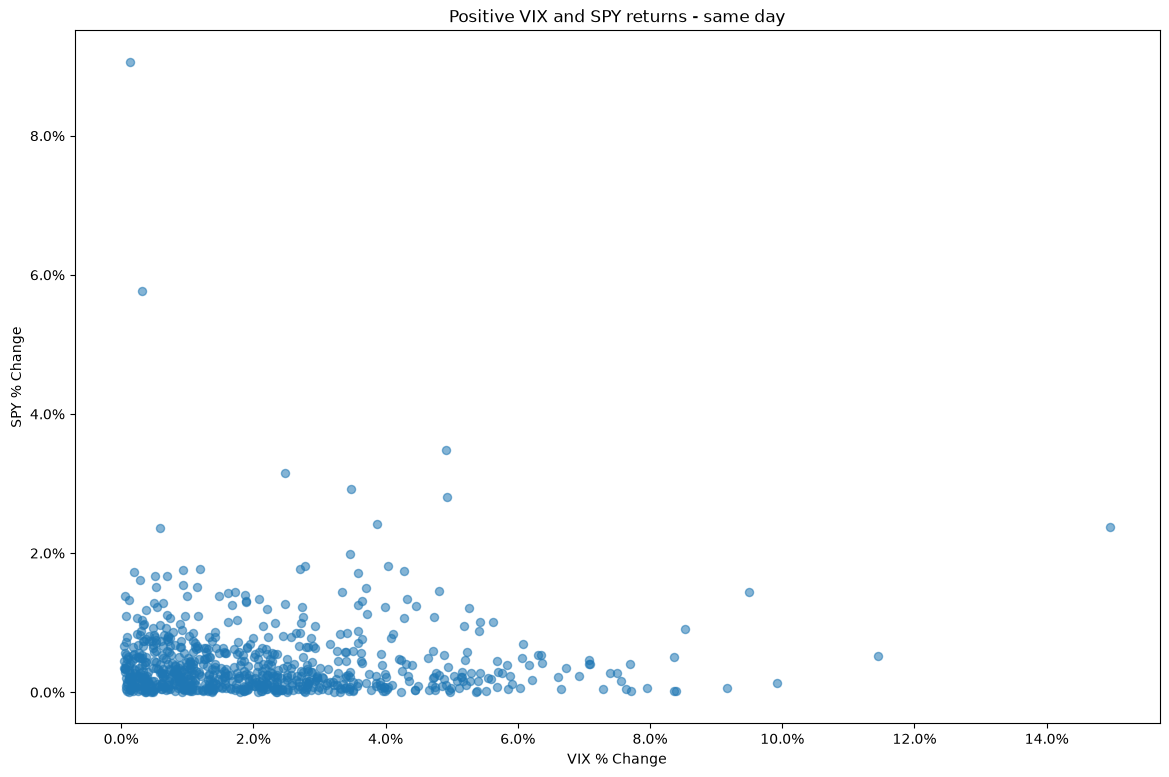

In [43]:
fig, ax = plt.subplots(figsize=(14, 9))

plot_df = df[(df['vix_diff']>0)&(df['spy_diff']>0)]

ax.scatter(plot_df['vix_diff'], plot_df['spy_diff'], s=34, alpha=.55)

#ax.scatter(df['SPY'].pct_change(1)['2026-07-30'],df['positive_1d']['2026-07-30'],s=38,alpha=1, c='red', marker=1)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
#ax.annotate('Thursday, July 30', (df['SPY'].pct_change(1)['2026-07-30'], df['positive_1d']['2026-07-30']), xytext=(4, 3), textcoords="offset points", fontsize=10)
ax.set(title=f"Positive VIX and SPY returns - same day", xlabel="VIX % Change", ylabel="SPY % Change")


AttributeError: 'numpy.ndarray' object has no attribute 'set'

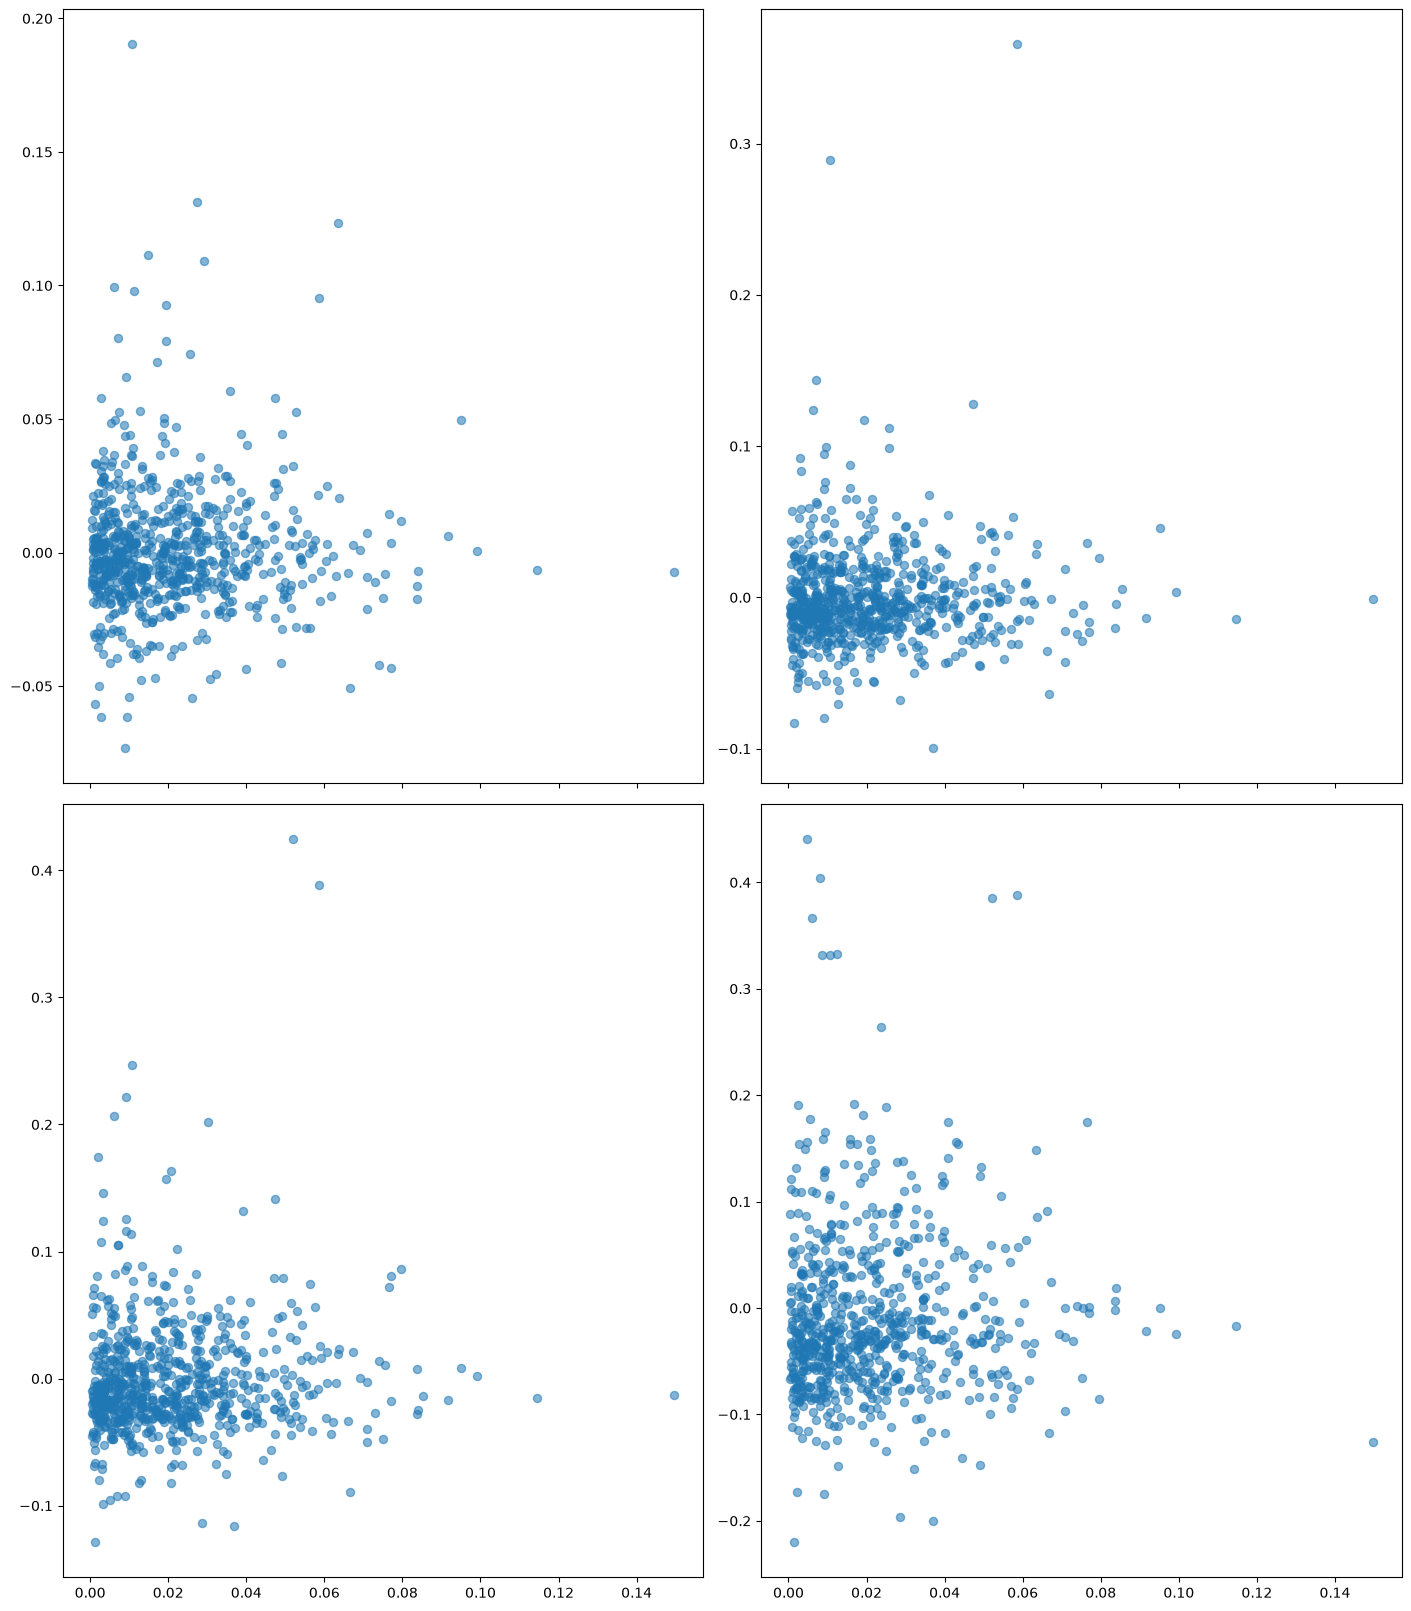

In [ ]:
#fig, ax = plt.subplots(figsize=(14, 9))

fig, axes = plt.subplots(2, 2, figsize=(14, 16), sharex=True, constrained_layout=True)

plot_df = df[(df['vix_diff']>0)&(df['spy_diff']>0)]

axes[0][0].scatter(plot_df['vix_diff'], plot_df['5d_fwd'], s=34, alpha=.55, label='5 day forward')
axes[0][1].scatter(plot_df['vix_diff'], plot_df['10d_fwd'], s=34, alpha=.55, label='10 day forward')
axes[1][0].scatter(plot_df['vix_diff'], plot_df['20d_fwd'], s=34, alpha=.55, label='20 day forward')
axes[1][1].scatter(plot_df['vix_diff'], plot_df['60d_fwd'], s=34, alpha=.55, label='60 day forward')

#ax.scatter(df['SPY'].pct_change(1)['2026-07-30'],df['positive_1d']['2026-07-30'],s=38,alpha=1, c='red', marker=1)
#axes.xaxis.set_major_formatter(PercentFormatter(1))
#axes.yaxis.set_major_formatter(PercentFormatter(1))
#ax.annotate('Thursday, July 30', (df['SPY'].pct_change(1)['2026-07-30'], df['positive_1d']['2026-07-30']), xytext=(4, 3), textcoords="offset points", fontsize=10)
#axes.set(title=f"Positive VIX and SPY returns - forward returns", xlabel="VIX % Change", ylabel="SPY % Change")


/var/folders/sk/b2sc5qdj3pv0n081pvpxq4_w0000gn/T/ipykernel_74741/1566754353.py:8: UserWarning: The pixel maker ',' is not supported on scatter(); using a finite-sized square instead, which is not necessarily 1 pixel in size. Use the square marker 's' instead to suppress this warning.
  ax.scatter(plot_df['vix_diff'], plot_df['10d_fwd'], s=34, alpha=.55, label='10 day forward',marker=',')


,5d_fwd,10d_fwd,20d_fwd,60d_fwd
count,635.000000,636.000000,637.000000,635.000000
mean,0.001428,0.000266,-0.000067,-0.006838
std,0.024189,0.033343,0.046369,0.077715
min,-0.061720,-0.099405,-0.115702,-0.200395
25%,-0.011233,-0.017536,-0.027020,-0.055255
50%,-0.002566,-0.005013,-0.008726,-0.024559
75%,0.010374,0.012522,0.017470,0.027804
max,0.190237,0.365537,0.424746,0.440816


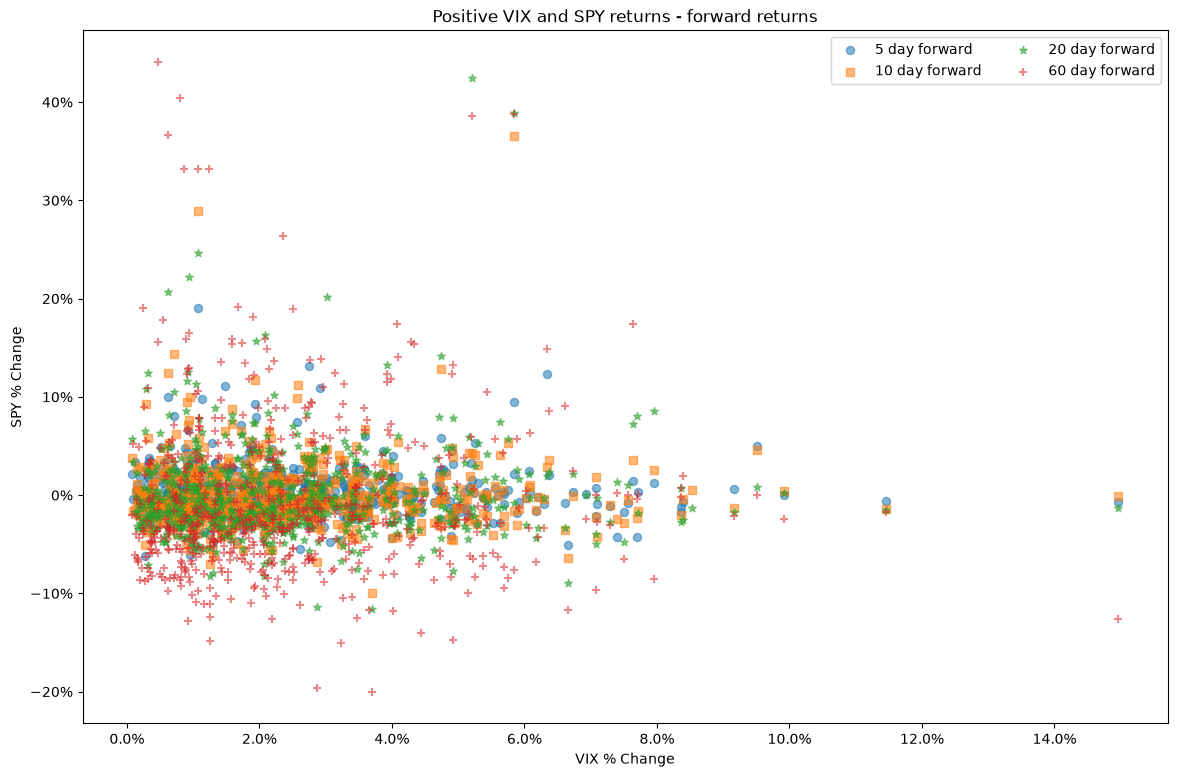

In [53]:
fig, ax = plt.subplots(figsize=(14, 9))

#fig, axes = plt.subplots(2, 2, figsize=(14, 16), sharex=True, constrained_layout=True)

plot_df = df[(df['vix_diff']>df['spy_diff'])&(df['spy_diff']>0)]

ax.scatter(plot_df['vix_diff'], plot_df['5d_fwd'], s=34, alpha=.55, label='5 day forward')
ax.scatter(plot_df['vix_diff'], plot_df['10d_fwd'], s=34, alpha=.55, label='10 day forward',marker=',')
ax.scatter(plot_df['vix_diff'], plot_df['20d_fwd'], s=34, alpha=.55, label='20 day forward',marker='*')
ax.scatter(plot_df['vix_diff'], plot_df['60d_fwd'], s=34, alpha=.55, label='60 day forward',marker='+')

#ax.scatter(df['SPY'].pct_change(1)['2026-07-30'],df['positive_1d']['2026-07-30'],s=38,alpha=1, c='red', marker=1)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
#ax.annotate('Thursday, July 30', (df['SPY'].pct_change(1)['2026-07-30'], df['positive_1d']['2026-07-30']), xytext=(4, 3), textcoords="offset points", fontsize=10)
ax.set(title=f"Positive VIX and SPY returns - forward returns", xlabel="VIX % Change", ylabel="SPY % Change")
ax.legend(ncol=2, fontsize=10, frameon=True, loc="best")

plot_df[['5d_fwd','10d_fwd','20d_fwd','60d_fwd']].describe()



/var/folders/sk/b2sc5qdj3pv0n081pvpxq4_w0000gn/T/ipykernel_74741/2366749191.py:8: UserWarning: The pixel maker ',' is not supported on scatter(); using a finite-sized square instead, which is not necessarily 1 pixel in size. Use the square marker 's' instead to suppress this warning.
  ax.scatter(plot_df['vix_diff'], plot_df['10d_fwd'], s=34, alpha=.55, label='10 day forward',marker=',')


,5d_fwd,10d_fwd,20d_fwd,60d_fwd
count,441.000000,443.000000,445.000000,441.000000
mean,-0.000309,-0.001537,-0.003383,-0.007103
std,0.015227,0.020772,0.031332,0.066449
min,-0.034856,-0.050853,-0.067206,-0.101301
25%,-0.010373,-0.015181,-0.025363,-0.047228
50%,-0.002798,-0.005182,-0.011059,-0.024559
75%,0.006286,0.008077,0.012727,0.019036
max,0.111293,0.099639,0.221971,0.440816


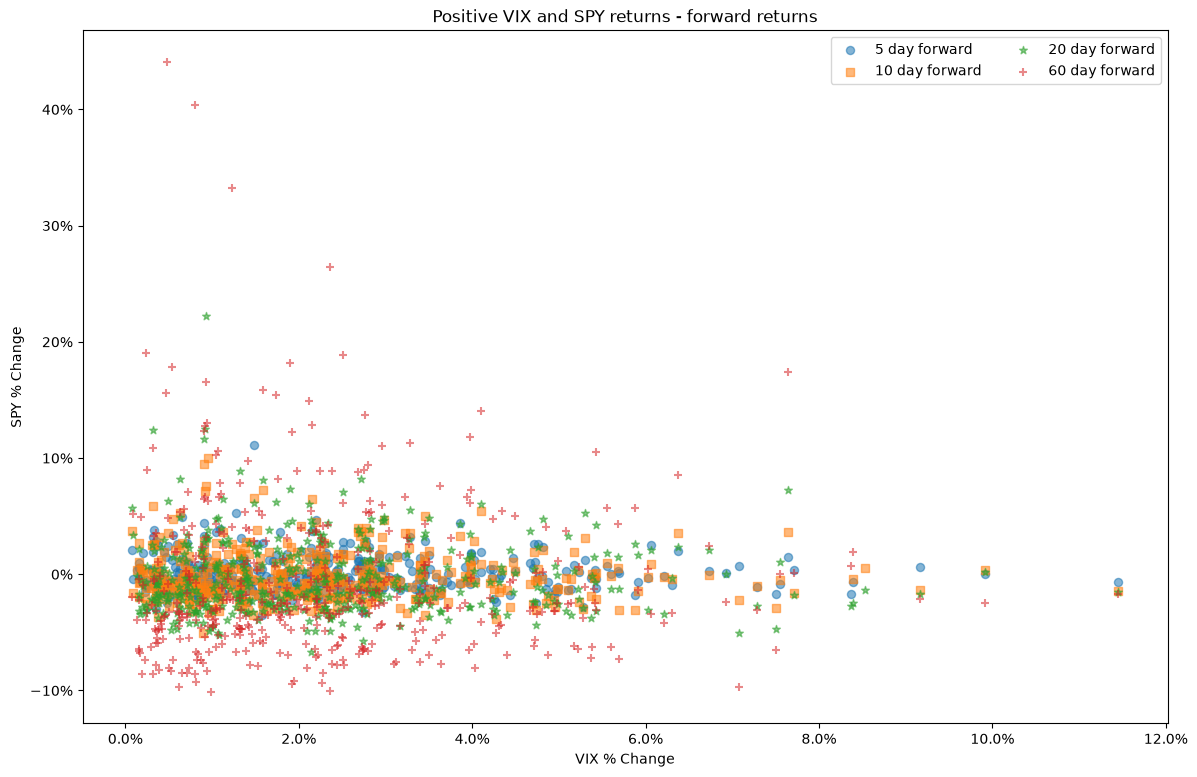

In [46]:
fig, ax = plt.subplots(figsize=(14, 9))

#fig, axes = plt.subplots(2, 2, figsize=(14, 16), sharex=True, constrained_layout=True)

plot_df = df[(df['vix_diff']>df['spy_diff'])&(df['spy_diff']>0)&(df['VIX']<=20)]

ax.scatter(plot_df['vix_diff'], plot_df['5d_fwd'], s=34, alpha=.55, label='5 day forward')
ax.scatter(plot_df['vix_diff'], plot_df['10d_fwd'], s=34, alpha=.55, label='10 day forward',marker=',')
ax.scatter(plot_df['vix_diff'], plot_df['20d_fwd'], s=34, alpha=.55, label='20 day forward',marker='*')
ax.scatter(plot_df['vix_diff'], plot_df['60d_fwd'], s=34, alpha=.55, label='60 day forward',marker='+')

#ax.scatter(df['SPY'].pct_change(1)['2026-07-30'],df['positive_1d']['2026-07-30'],s=38,alpha=1, c='red', marker=1)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
#ax.annotate('Thursday, July 30', (df['SPY'].pct_change(1)['2026-07-30'], df['positive_1d']['2026-07-30']), xytext=(4, 3), textcoords="offset points", fontsize=10)
ax.set(title=f"Positive VIX and SPY returns - forward returns", xlabel="VIX % Change", ylabel="SPY % Change")
ax.legend(ncol=2, fontsize=10, frameon=True, loc="best")

plot_df[['5d_fwd','10d_fwd','20d_fwd','60d_fwd']].describe()


/var/folders/sk/b2sc5qdj3pv0n081pvpxq4_w0000gn/T/ipykernel_74741/2810889107.py:7: UserWarning: The pixel maker ',' is not supported on scatter(); using a finite-sized square instead, which is not necessarily 1 pixel in size. Use the square marker 's' instead to suppress this warning.
  axes[0].scatter(plot_df['vix_diff'], plot_df['10d_fwd'], s=34, alpha=.55, label='10 day forward',marker=',')
/var/folders/sk/b2sc5qdj3pv0n081pvpxq4_w0000gn/T/ipykernel_74741/2810889107.py:24: UserWarning: The pixel maker ',' is not supported on scatter(); using a finite-sized square instead, which is not necessarily 1 pixel in size. Use the square marker 's' instead to suppress this warning.
  axes[1].scatter(plot_df['vix_diff'], plot_df['10d_fwd'], s=34, alpha=.55, label='10 day forward',marker=',')


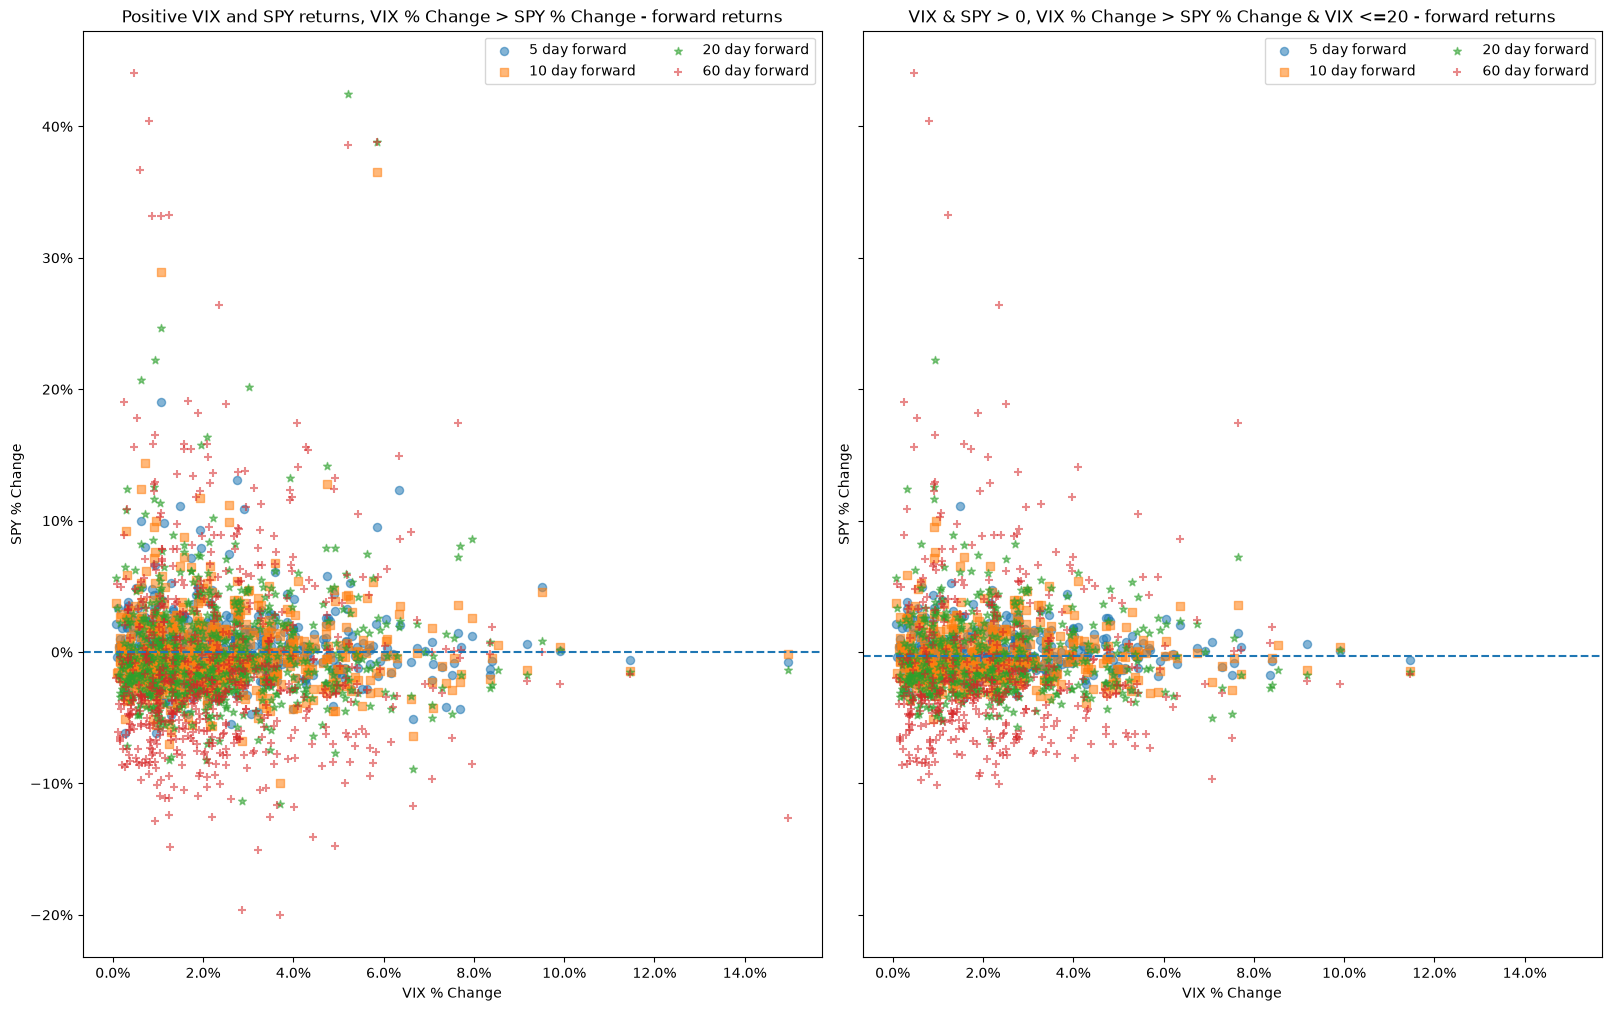

In [82]:
fig, axes = plt.subplots(1,2 , figsize=(16, 10), sharex=True, sharey=True, constrained_layout=True)


plot_df = df[(df['vix_diff']>df['spy_diff'])&(df['spy_diff']>0)]

axes[0].scatter(plot_df['vix_diff'], plot_df['5d_fwd'], s=34, alpha=.55, label='5 day forward')
axes[0].scatter(plot_df['vix_diff'], plot_df['10d_fwd'], s=34, alpha=.55, label='10 day forward',marker=',')
axes[0].scatter(plot_df['vix_diff'], plot_df['20d_fwd'], s=34, alpha=.55, label='20 day forward',marker='*')
axes[0].scatter(plot_df['vix_diff'], plot_df['60d_fwd'], s=34, alpha=.55, label='60 day forward',marker='+')

#ax.scatter(df['SPY'].pct_change(1)['2026-07-30'],df['positive_1d']['2026-07-30'],s=38,alpha=1, c='red', marker=1)
axes[0].xaxis.set_major_formatter(PercentFormatter(1))
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
#ax.annotate('Thursday, July 30', (df['SPY'].pct_change(1)['2026-07-30'], df['positive_1d']['2026-07-30']), xytext=(4, 3), textcoords="offset points", fontsize=10)
axes[0].set(title=f"Positive VIX and SPY returns, VIX % Change > SPY % Change - forward returns", xlabel="VIX % Change", ylabel="SPY % Change")
axes[0].legend(ncol=2, fontsize=10, frameon=True, loc="best")

axes[0].axhline(plot_df['20d_fwd'].mean(),linestyle='--')


plot_df = df[(df['vix_diff']>df['spy_diff'])&(df['spy_diff']>0)&(df['VIX']<=20)]

axes[1].scatter(plot_df['vix_diff'], plot_df['5d_fwd'], s=34, alpha=.55, label='5 day forward')
axes[1].scatter(plot_df['vix_diff'], plot_df['10d_fwd'], s=34, alpha=.55, label='10 day forward',marker=',')
axes[1].scatter(plot_df['vix_diff'], plot_df['20d_fwd'], s=34, alpha=.55, label='20 day forward',marker='*')
axes[1].scatter(plot_df['vix_diff'], plot_df['60d_fwd'], s=34, alpha=.55, label='60 day forward',marker='+')

#ax.scatter(df['SPY'].pct_change(1)['2026-07-30'],df['positive_1d']['2026-07-30'],s=38,alpha=1, c='red', marker=1)
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
#ax.annotate('Thursday, July 30', (df['SPY'].pct_change(1)['2026-07-30'], df['positive_1d']['2026-07-30']), xytext=(4, 3), textcoords="offset points", fontsize=10)
axes[1].set(title=f"VIX & SPY > 0, VIX % Change > SPY % Change & VIX <=20 - forward returns", xlabel="VIX % Change", ylabel="SPY % Change")
axes[1].legend(ncol=2, fontsize=10, frameon=True, loc="best")
axes[1].axhline(plot_df['20d_fwd'].mean(),linestyle='--')



count    447.000000
mean      11.689075
std        5.035127
min        3.570600
25%        8.244615
50%       10.540608
75%       14.246603
max       51.282206
Name: fwd_realized_vol, dtype: float64

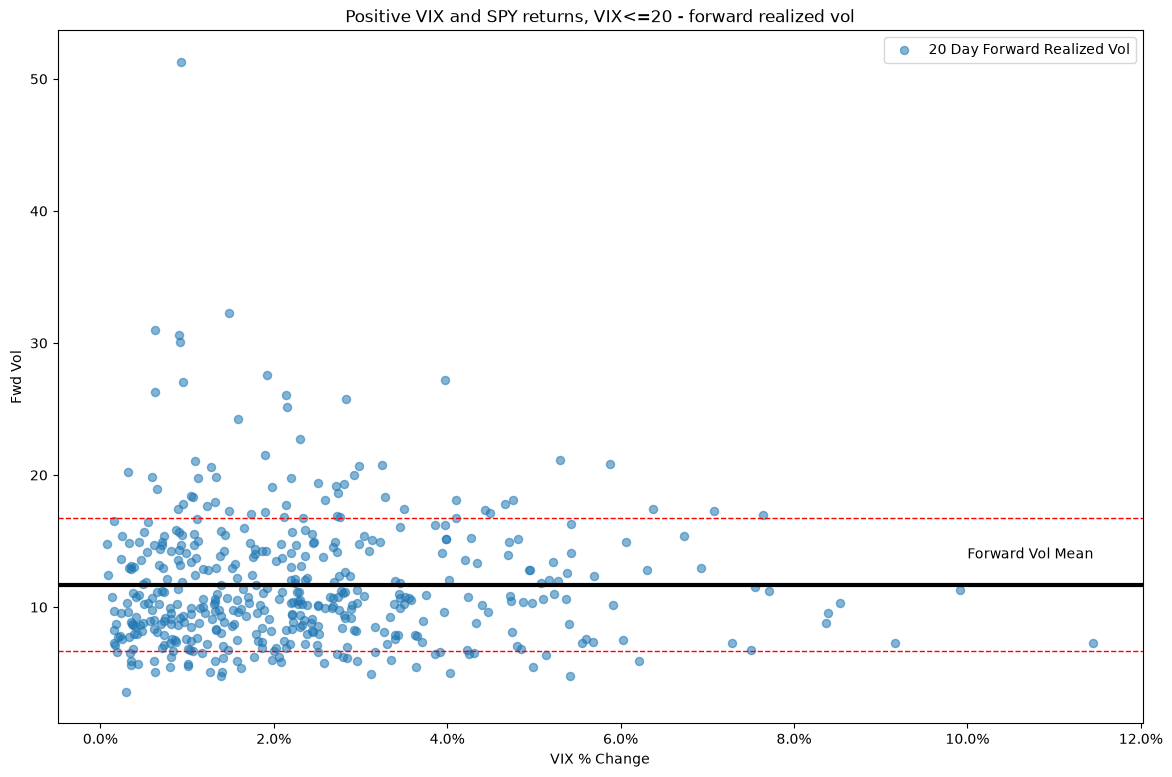

In [99]:
fig, ax = plt.subplots(figsize=(14, 9))

#fig, axes = plt.subplots(2, 2, figsize=(14, 16), sharex=True, constrained_layout=True)

plot_df = df[(df['vix_diff']>df['spy_diff'])&(df['spy_diff']>0)&(df['VIX']<=20)]

ax.scatter(plot_df['vix_diff'], plot_df['fwd_realized_vol'], s=34, alpha=.55, label='20 Day Forward Realized Vol')


#ax.scatter(df['SPY'].pct_change(1)['2026-07-30'],df['positive_1d']['2026-07-30'],s=38,alpha=1, c='red', marker=1)
ax.xaxis.set_major_formatter(PercentFormatter(1))
#ax.yaxis.set_major_formatter(PercentFormatter(1))
#ax.annotate('Thursday, July 30', (df['SPY'].pct_change(1)['2026-07-30'], df['positive_1d']['2026-07-30']), xytext=(4, 3), textcoords="offset points", fontsize=10)
ax.set(title=f"Positive VIX and SPY returns, VIX<=20 - forward realized vol", xlabel="VIX % Change", ylabel="Fwd Vol")
ax.legend(ncol=2, fontsize=10, frameon=True, loc="best")

ax.axhline(plot_df['fwd_realized_vol'].mean(),linewidth = 3,color='k')
ax.axhline(plot_df['fwd_realized_vol'].mean()+plot_df['fwd_realized_vol'].std(),linewidth = 1,color='r',linestyle='--')

ax.axhline(plot_df['fwd_realized_vol'].mean()-plot_df['fwd_realized_vol'].std(),linewidth = 1,color='r',linestyle='--')

ax.annotate('Forward Vol Mean',xy=(0.1,plot_df['fwd_realized_vol'].mean()+2))


plot_df['fwd_realized_vol'].describe()
#plot_df[['5d_fwd','10d_fwd','20d_fwd','60d_fwd']].describe()


count    3383.000000
mean       17.371023
std        11.209861
min         3.570600
25%        10.488737
50%        14.778085
75%        20.784177
max        94.249042
Name: fwd_realized_vol, dtype: float64

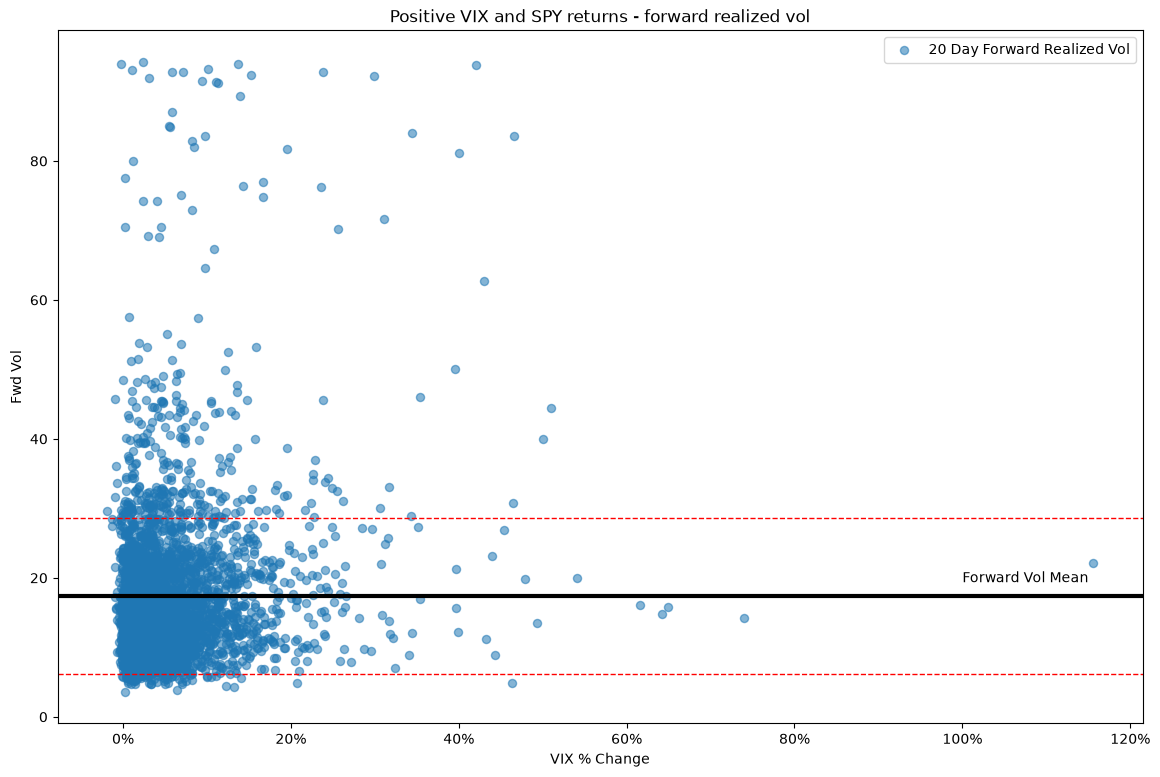

In [ ]:
fig, ax = plt.subplots(figsize=(14, 9))

#fig, axes = plt.subplots(2, 2, figsize=(14, 16), sharex=True, constrained_layout=True)

plot_df = df[(df['vix_diff']>df['spy_diff'])]

ax.scatter(plot_df['vix_diff'], plot_df['fwd_realized_vol'], s=34, alpha=.55, label='20 Day Forward Realized Vol')
blob:vscode-webview://1m5ov9u529n7glua5r74nud4e26o5kjip3qqmauosbtrcgh4efps/d92faddc-1cde-4720-9392-40dfe8ac6f2a

#ax.scatter(df['SPY'].pct_change(1)['2026-07-30'],df['positive_1d']['2026-07-30'],s=38,alpha=1, c='red', marker=1)
ax.xaxis.set_major_formatter(PercentFormatter(1))
#ax.yaxis.set_major_formatter(PercentFormatter(1))
#ax.annotate('Thursday, July 30', (df['SPY'].pct_change(1)['2026-07-30'], df['positive_1d']['2026-07-30']), xytext=(4, 3), textcoords="offset points", fontsize=10)
ax.set(title=f"Positive VIX and SPY returns - forward realized vol", xlabel="VIX % Change", ylabel="Fwd Vol")
ax.legend(ncol=2, fontsize=10, frameon=True, loc="best")

ax.axhline(plot_df['fwd_realized_vol'].mean(),linewidth = 3,color='k')
ax.axhline(plot_df['fwd_realized_vol'].mean()+plot_df['fwd_realized_vol'].std(),linewidth = 1,color='r',linestyle='--')

ax.axhline(plot_df['fwd_realized_vol'].mean()-plot_df['fwd_realized_vol'].std(),linewidth = 1,color='r',linestyle='--')
ax.annotate('Forward Vol Mean',xy=(1,plot_df['fwd_realized_vol'].mean()+2))


plot_df['fwd_realized_vol'].describe()

#plot_df[['5d_fwd','10d_fwd','20d_fwd','60d_fwd']].describe()


count    1844.000000
mean       12.287703
std         5.988094
min         3.570600
25%         8.768308
50%        11.050134
75%        14.402132
max        83.664582
Name: fwd_realized_vol, dtype: float64

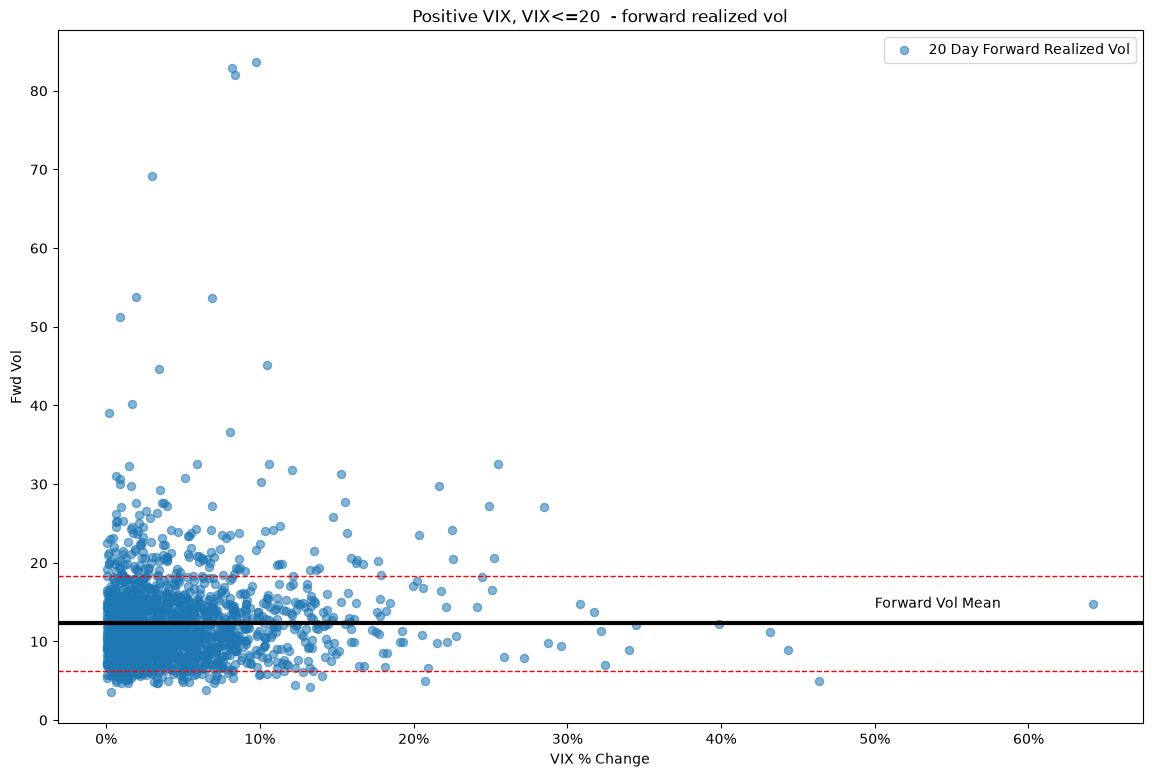

In [98]:
fig, ax = plt.subplots(figsize=(14, 9))

#fig, axes = plt.subplots(2, 2, figsize=(14, 16), sharex=True, constrained_layout=True)

plot_df = df[(df['vix_diff']>0)&(df['VIX']<=20)]

ax.scatter(plot_df['vix_diff'], plot_df['fwd_realized_vol'], s=34, alpha=.55, label='20 Day Forward Realized Vol')


#ax.scatter(df['SPY'].pct_change(1)['2026-07-30'],df['positive_1d']['2026-07-30'],s=38,alpha=1, c='red', marker=1)
ax.xaxis.set_major_formatter(PercentFormatter(1))
#ax.yaxis.set_major_formatter(PercentFormatter(1))
#ax.annotate('Thursday, July 30', (df['SPY'].pct_change(1)['2026-07-30'], df['positive_1d']['2026-07-30']), xytext=(4, 3), textcoords="offset points", fontsize=10)
ax.set(title=f"Positive VIX, VIX<=20  - forward realized vol", xlabel="VIX % Change", ylabel="Fwd Vol")

ax.axhline(plot_df['fwd_realized_vol'].mean(),linewidth = 3,color='k')
ax.axhline(plot_df['fwd_realized_vol'].mean()+plot_df['fwd_realized_vol'].std(),linewidth = 1,color='r',linestyle='--')

ax.axhline(plot_df['fwd_realized_vol'].mean()-plot_df['fwd_realized_vol'].std(),linewidth = 1,color='r',linestyle='--')

ax.annotate('Forward Vol Mean',xy=(0.5,plot_df['fwd_realized_vol'].mean()+2))

ax.legend(ncol=2, fontsize=10, frameon=True, loc="best")

plot_df['fwd_realized_vol'].describe()


#plot_df[['5d_fwd','10d_fwd','20d_fwd','60d_fwd']].describe()


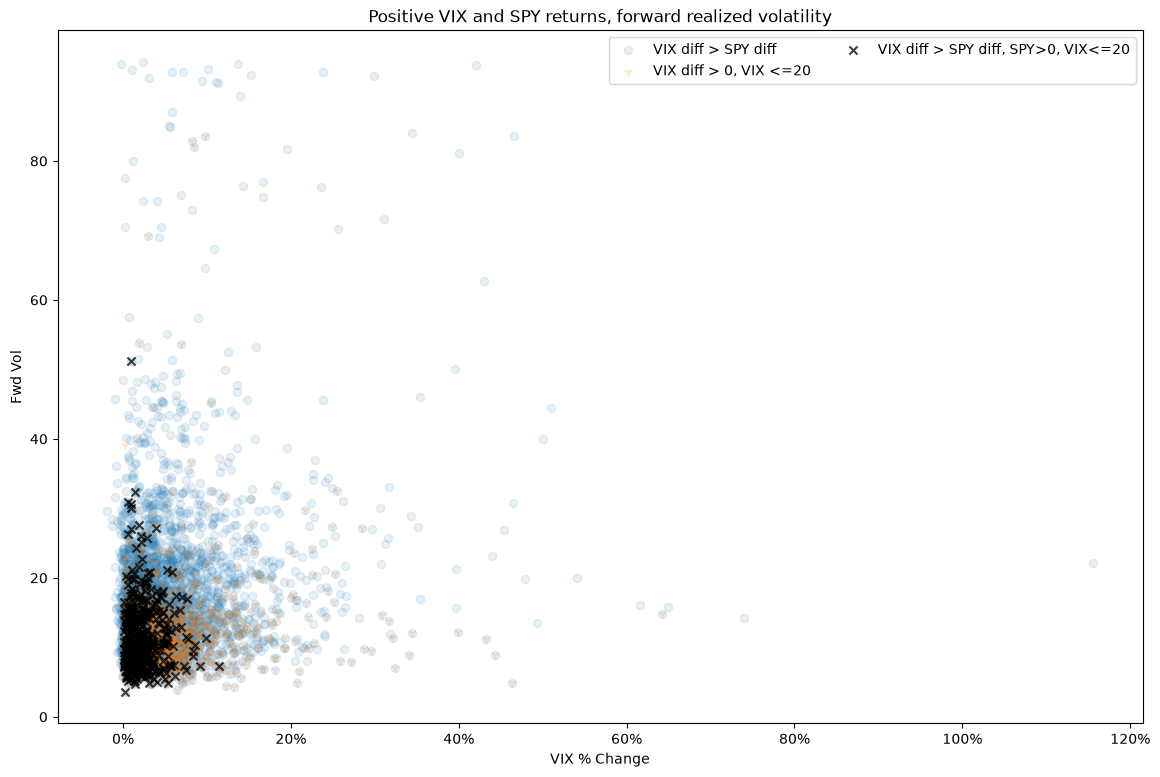

In [79]:
fig, ax = plt.subplots(figsize=(14, 9))

#fig, axes = plt.subplots(2, 2, figsize=(14, 16), sharex=True, constrained_layout=True)


plot_df = df[(df['vix_diff']>df['spy_diff'])]

ax.scatter(plot_df['vix_diff'], plot_df['fwd_realized_vol'], s=34, alpha=.11, label='VIX diff > SPY diff')


plot_df = df[(df['vix_diff']>0)&(df['VIX']<=20)]

ax.scatter(plot_df['vix_diff'], plot_df['fwd_realized_vol'], s=34, alpha=.21, label='VIX diff > 0, VIX <=20', marker='1')

plot_df = df[(df['vix_diff']>df['spy_diff'])&(df['spy_diff']>0)&(df['VIX']<=20)]

ax.scatter(plot_df['vix_diff'], plot_df['fwd_realized_vol'], s=34, alpha=.75, label='VIX diff > SPY diff, SPY>0, VIX<=20', marker='x', c='black')


#ax.scatter(df['SPY'].pct_change(1)['2026-07-30'],df['positive_1d']['2026-07-30'],s=38,alpha=1, c='red', marker=1)
ax.xaxis.set_major_formatter(PercentFormatter(1))
#ax.yaxis.set_major_formatter(PercentFormatter(1))
#ax.annotate('Thursday, July 30', (df['SPY'].pct_change(1)['2026-07-30'], df['positive_1d']['2026-07-30']), xytext=(4, 3), textcoords="offset points", fontsize=10)
ax.set(title=f"Positive VIX and SPY returns, forward realized volatility", xlabel="VIX % Change", ylabel="Fwd Vol")
ax.legend(ncol=2, fontsize=10, frameon=True, loc="best")

#plot_df[['5d_fwd','10d_fwd','20d_fwd','60d_fwd']].describe()
